https://github.com/zh217/torch-dct

# Contents
Same as 03_dequant-quant (final model), using a smaller learning rate: 1e-5 instead of 1e-4. To be fair, I should use more steps in order to allowd the model to converge as in the previous ones. However, keeping the same steps may allow to reduce overfitting, and more or less it would converge anyway a few steps before with higher lr. let's see with the learning curve



# Imports
Installing libraries, importing them

In [ ]:
! pip install torch torchvision
! pip install matplotlib
! pip install comet_ml
! pip install einops
! pip install torchgeometry
! pip install jpegio
! pip install torch_dct
! pip install kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.6/796.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.6 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 MB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jpegio: filename=jpegio-0.2.8-cp312-cp312-linux_x86_64.whl size=1288664 sha256=c34fade9f60bf8bd90be4cc84512790f9c70c432ca737671866f4a554b764779
  Stored in directory: /root/.cache/pip/wheels/4e/5f/d9/3898c36bd7e9166a13a514d61f7ddd7310c192bfb443e758f8
Successfully built jpegio
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:00
   ━━━

In [ ]:
import torch
import torchvision
from pathlib import Path
from PIL import Image
import sys
import os
import shutil
from torchvision import transforms
import matplotlib.pyplot as plt

# dataloader
from torch.utils.data import Dataset, DataLoader, random_split

# jpeg
import torch_dct as dct
import numpy as np
import tempfile
import matplotlib.pyplot as plt
import kornia
import torch_dct

# to store-reload best model
from contextlib import redirect_stdout
import io
import json
import gc
from collections import OrderedDict

# for testing
from torchvision.utils import save_image

In [ ]:
print(torch.cuda.is_available()) # Should return True

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Base path
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
NAME = "06_dequant-quant_smaller_lr"

# Directories
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")
LOCAL_DATA_ROOT = "/content/raw_data"
SRC_C_D = os.path.join(BASE_DIR, "src", "Cold-Diffusion-Models", "resolution-diffusion-pytorch", "resolution_diffusion_pytorch")
QUANT_TABLES = os.path.join(BASE_DIR, "assets/dequant-quant3_qt.pt")

CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints", "coeff_quantized", "1_final_degradation_function", NAME)
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "trainings", "coeff_quantized", "1_final_degradation_function", NAME)
TRAINED_MODEL_DIR = os.path.join(BASE_DIR, "trained_models", "cold_diffusion", "coeff_quantized", "1_final_degradation_function", NAME)

# importing the models
if SRC_C_D not in sys.path:
    sys.path.append(SRC_C_D)

# 6. Creazione cartelle
for path in [CHECKPOINT_DIR, OUTPUT_DIR, TRAINED_MODEL_DIR]:
    os.makedirs(path, exist_ok=True)


In [ ]:
if not os.path.exists(LOCAL_DATA_ROOT):
    print("Unzipping ...")
    !unzip -q "{ZIP_PATH}" -d {LOCAL_DATA_ROOT}
    print("Done!")
else:
    print("Already unzipped")

Unzipping ...
Done!


In [ ]:
save_path = os.path.join(TRAINED_MODEL_DIR, f'{NAME}.pt')

TRAIN = True
TEST = True

# Loading and PreProcessing

In [ ]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        # Prendiamo tutti i file una volta sola
        self.file_names = [f for f in os.listdir(root_dir) if f.endswith(('.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# Transform configuration
IMG_SIZE = 128
train_transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1) # Normalize to [-1,1] for diffusion
])

batch_size_ = 8

In [ ]:
# Loading dataset
dataset_path = os.path.join(LOCAL_DATA_ROOT, "img_align_celeba")
full_dataset = CelebADataset(root_dir=dataset_path, transform=train_transform)

# Split random
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size_, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size_, shuffle=False, num_workers=2)

print(f"Dataset ready. Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Dataset ready. Train: 182339 | Test: 20260


Batch Shape: torch.Size([8, 3, 128, 128])
Range: Min=-1.00, Max=1.00


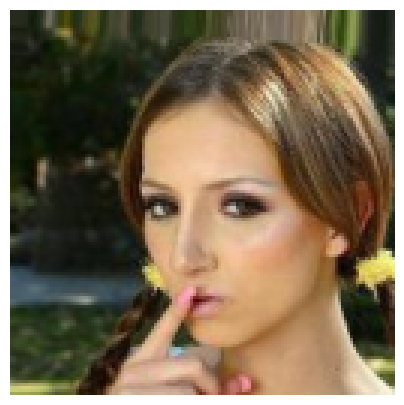

In [ ]:
def sanity_check_dataloader(dataloader):
    try:
        batch = next(iter(dataloader))
    except Exception as e:
        print(f"Error in loading batch: {e}")
        return

    # Il batch ha forma [8, 3, 128, 128]
    print(f"Batch Shape: {batch.shape}")
    print(f"Range: Min={batch.min():.2f}, Max={batch.max():.2f}")

    img_t = batch[0]

    # Denormalizzazione da [-1, 1] a [0, 1] per la visualizzazione
    img_viz = (img_t + 1) / 2
    img_viz = img_viz.clamp(0, 1)

    # Conversione in formato [H, W, C] per matplotlib
    img_np = img_viz.permute(1, 2, 0).numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(img_np)
    plt.axis('off')
    plt.show()

sanity_check_dataloader(train_loader)

# Configuration

In [ ]:
IMG_SIZE = 128
batch_size_ = 16

In [ ]:
quant_tables = torch.load(QUANT_TABLES)

### Defining the new degradation function

Now I configure the model using the classes of the authors

In [ ]:
# questo serve per eliminare conflitti col file celeb_128, dato che già chiama args
sys.argv = ['colab_kernel_launcher.py']

from resolution_diffusion_pytorch import Unet, GaussianDiffusion, Trainer

def find_last_checkpoint(save_folder):
    path = os.path.join(save_folder, f'model.pt')
    if os.path.exists(path):
        return path
    return None

In [ ]:
from torch._prims_common import check
# --- CONFIGURATION ---
class Args:
    time_steps = 10           # Steps to lose information
    train_steps = 5000      # Total iterations
    save_folder = OUTPUT_DIR    # for images
    data_path = dataset_path
    checkpoint_path = CHECKPOINT_DIR
    load_path = find_last_checkpoint(checkpoint_path)  # Path to weights to resume
    train_routine = 'Final'
    resolution_routine = 'Incremental'
    sampling_routine = 'x0_step_down'
    image_size = IMG_SIZE
    channels = 3

args = Args()

# --- MODEL INITIALIZATION ---
model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels = args.channels
).cuda()

diffusion = GaussianDiffusion(
    model,
    image_size = args.image_size,
    device_of_kernel = 'cuda',
    channels = args.channels,
    timesteps = args.time_steps,
    loss_type = 'l1',
    resolution_routine = args.resolution_routine,
    train_routine = args.train_routine,
    sampling_routine = args.sampling_routine
).cuda()

# Support for multiple GPUs if available
if torch.cuda.device_count() > 1:
    diffusion = torch.nn.DataParallel(diffusion)

# il dummy wrapper è un escamotage per una serie di problemi che mi dava
# tra i quali il fatto che si aspettava di ricevere un argomento module
class DummyWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.module = model

    def forward(self, *args, **kwargs):
        return self.module(*args, **kwargs)

    # Questo metodo reindirizza ogni chiamata non trovata al modello interno
    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.module, name)

# Applico il wrapper se non è già DataParallel
if not isinstance(diffusion, torch.nn.DataParallel):
    diffusion = DummyWrapper(diffusion)
    print("DummyWrapper aggiornato")

# Correctly initialize Trainer by passing the train_dataset object
# and removing the 'dataset = custom' argument from Args as it's no longer needed.
trainer = Trainer(
    diffusion,
    dataset_path,
    image_size = args.image_size,
    train_batch_size = 16,
    train_lr = 1e-5,
    train_num_steps = args.train_steps,
    ema_decay = 0.995,
    fp16 = False,
    results_folder = args.save_folder,
    load_path = args.load_path,
    save_and_sample_every = 25,
    gradient_accumulate_every = 2
    )
trainer.checkpoint_path = Path(args.checkpoint_path)

Is Time embed used ?  True
DummyWrapper aggiornato
Loading :  /content/drive/MyDrive/Colab Notebooks/tesi/checkpoints/coeff_quantized/1_final_degradation_function/06_dequant-quant_smaller_lr/model.pt


COSA CAMBIA:

in pratica ho tenuto il q_sample originale, il quale passa l'immagine allo step attuale s da degradare per lo step s+1.

la differenza è che memorizzo l'immagine al primo step (come coefficienti), in modo tale da poter appplicare la degradazione in modo non cumulativo. poi ritrasformo in immagine solo per passarla al q_sample [idct]

non uso l'immagine allo step s per degradare allo step s+1

In [ ]:
# Stato condiviso tra step consecutivi - valido solo per la durata di q_sample
_dct_state = {
    'coeffs': None,     # coefficienti DCT reali (non quantizzati) - aggiornati ad ogni step
    'step': -1,         # ultimo step applicato
}

def get_quant_table_tensor(step, device):
    lum  = quant_tables[f'step{step}_luminance'].to(device)    # [8, 8]
    chrom = quant_tables[f'step{step}_chrominance'].to(device) # [8, 8]
    return lum, chrom

def img_to_dct_blocks(img_batch):
    """
    Pixel space [-1,1] → coefficienti DCT in spazio blocchi.
    Restituisce (blocks_dct, bH, bW) dove blocks_dct shape [B, C, bH*bW, 8, 8].
    """
    B, C, H, W = img_batch.shape
    x = (img_batch + 1) * 0.5                          # [-1,1] → [0,1]
    x_ycbcr = kornia.color.rgb_to_ycbcr(x)             # [0,1] YCbCr
    x_255 = x_ycbcr * 255.0                            # [0,255]

    blocks = x_255.unfold(2, 8, 8).unfold(3, 8, 8)     # [B,C,bH,bW,8,8]
    bH, bW = blocks.shape[2], blocks.shape[3]
    blocks_flat = blocks.contiguous().reshape(B, C, bH * bW, 8, 8)
    dct_blocks = dct.dct_2d(blocks_flat, norm='ortho')  # [B,C,bH*bW,8,8]
    return dct_blocks, bH, bW

def dct_blocks_to_img(dct_blocks, bH, bW, B, C, H, W):
    """
    Coefficienti DCT → pixel space [-1,1].
    """
    result_flat = dct.idct_2d(dct_blocks, norm='ortho')
    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H, W)
    result_01 = (result / 255.0).clamp(0, 1)
    result_rgb = kornia.color.ycbcr_to_rgb(result_01)
    return (result_rgb * 2 - 1).clamp(-1, 1)

def quantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Quantizza coefficienti DCT con tabelle luma/chroma.
    Restituisce coefficienti quantizzati (ancora in float, non divisi per q).
    """
    q_lum   = q_lum.unsqueeze(0).unsqueeze(0)    # [1,1,8,8]
    q_chrom = q_chrom.unsqueeze(0).unsqueeze(0)  # [1,1,8,8]
    out = dct_blocks.clone()
    out[:, 0:1] = torch.round(dct_blocks[:, 0:1] / q_lum)   * q_lum
    # out[:, 1:3] = torch.round(dct_blocks[:, 1:3] / q_chrom) * q_chrom
    # TODO: capire se tenere quantizzazione chroma o meno
    return out

def dequantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Dequantizza: rimuove la quantizzazione corrente per tornare ai coefficienti reali.
    I coefficienti sono già in forma 'dequantizzata' (× q), quindi questa funzione
    NON fa nulla se i coefficienti sono già in forma reale — serve solo se hai
    salvato i coefficienti come quozienti interi (÷ q senza rimoltiplicare).

    Nel nostro caso, quantize_dct salva già i coefficienti moltiplicati (forma reale),
    quindi dequantize è implicita: i coefficienti in _dct_state sono già "reali".
    """
    # No-op: i coefficienti in _dct_state sono già in forma reale (× q già applicato)
    return dct_blocks

def jpeg_degradation(img_batch, step):
    """
    Degradazione JPEG cumulativa in spazio DCT puro.

    Flusso per step t:
      - Se step==0: nessuna degradazione, resetta stato
      - Se step==1: DCT da zero sull'immagine originale → quantizza con table[1]
      - Se step>1:  dequantizza table[t-1] (no-op, già in forma reale)
                    → quantizza con table[t] → aggiorna stato

    La cumulatività è garantita perché:
      - Non c'è mai IDCT intermedia tra step consecutivi
      - Si opera sempre sui coefficienti DCT dell'immagine originale
        riapplicando la nuova tabella (non sulla versione già quantizzata)
    """
    device = img_batch.device
    current_step = step.item() if torch.is_tensor(step) else step

    if current_step == 0:
        # Reset stato, nessuna degradazione
        _dct_state['coeffs'] = None
        _dct_state['step'] = -1
        return img_batch

    B, C, H, W = img_batch.shape

    # Step 1: calcola DCT dall'immagine in ingresso (che a step==1 è x_start)
    # Step >1: usa i coefficienti DCT originali già in cache, NON rifà DCT su img_batch
    #          (img_batch a step>1 è l'output IDCT del passo precedente, rumoroso)
    if current_step == 1 or _dct_state['coeffs'] is None:
        # Prima volta: calcola DCT dall'immagine originale
        dct_blocks, bH, bW = img_to_dct_blocks(img_batch)
        _dct_state['original_dct'] = dct_blocks.clone()  # salva originale
        _dct_state['bH'] = bH
        _dct_state['bW'] = bW
    else:
        # Step successivi: riparte sempre dall'originale per applicare nuova tabella
        # Ensure dct_blocks is on the current device
        dct_blocks = _dct_state['original_dct'].to(device)
        bH = _dct_state['bH']
        bW = _dct_state['bW']

    # Applica tabella dello step corrente direttamente sui coefficienti originali
    q_lum, q_chrom = get_quant_table_tensor(current_step, device)
    quantized = quantize_dct(dct_blocks, q_lum, q_chrom)

    # Aggiorna stato
    _dct_state['coeffs'] = quantized
    _dct_state['step'] = current_step

    return dct_blocks_to_img(quantized, bH, bW, B, C, H, W)


In [ ]:
# --- SOVRASCRITTURA ---
inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]

### Testing the new function

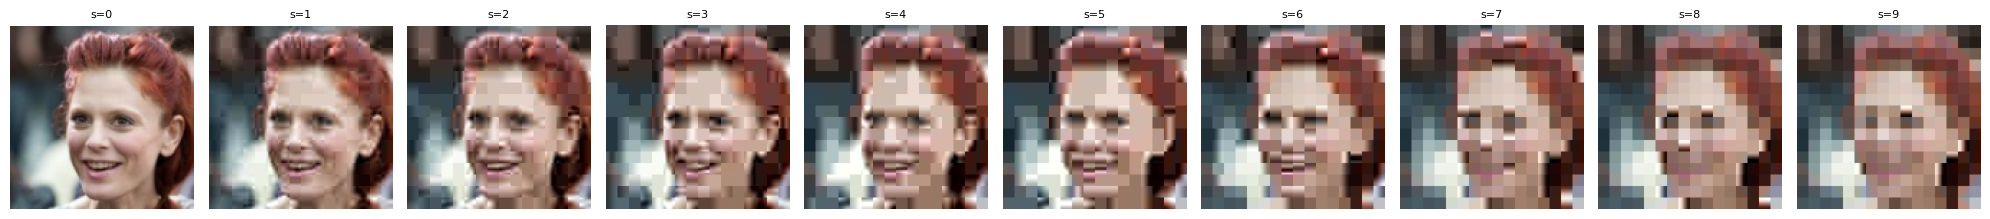

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define the device to use (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fig, axs = plt.subplots(1, 10, figsize=(20, 3))

img_path = '/content/raw_data/img_align_celeba/000002.jpg' # Using one of the generated images

# Load the image and apply transformations
x_test_pil = Image.open(img_path).convert('RGB')
x_test_tensor = train_transform(x_test_pil).unsqueeze(0).to(device) # Add batch dimension and move to device

for step in range(10):
    t = torch.tensor([step], device=device) # Move tensor 't' to the defined device as well
    x_deg = jpeg_degradation(x_test_tensor, t)
    img_vis = ((x_deg.squeeze().permute(1,2,0) + 1) * 0.5).cpu().numpy()
    axs[step].imshow(img_vis.clip(0,1))
    axs[step].set_title(f"s={step}", fontsize=8)
    axs[step].axis('off')
plt.tight_layout()
plt.show()

Degradation (DCT)...
Range image: [-1.0, 1.0]


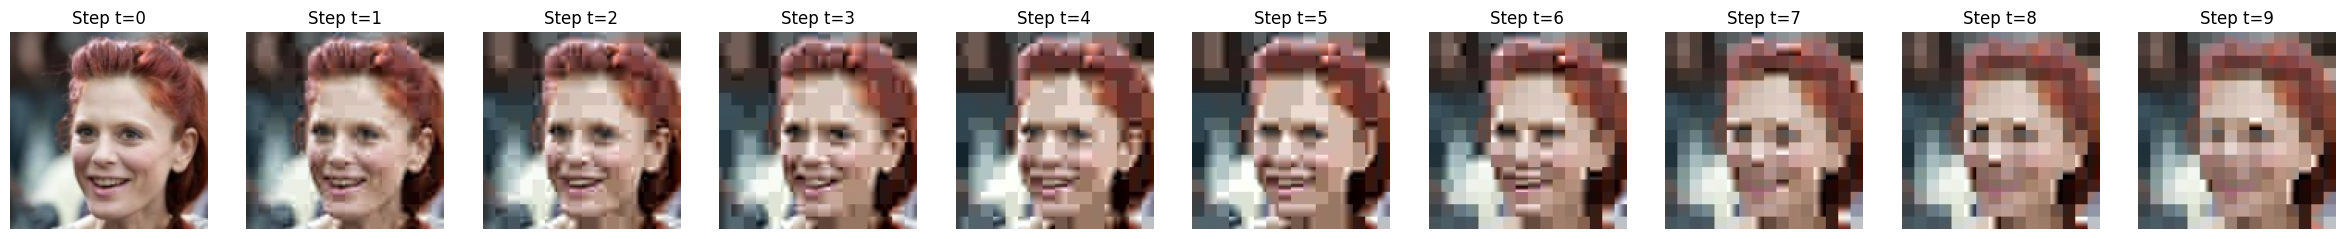

In [ ]:
def show_degradation(img_path, steps_to_show):
    x_0_pil = Image.open(img_path)     # taking first image of the batch

    x_0_processed = train_transform(x_0_pil)  # Apply the same transformations as during training
    x_0 = x_0_processed.unsqueeze(0).to('cuda') # Add batch dimension and move to GPU

    # visualization parameters # Show all steps
    n_steps = len(steps_to_show)

    # Ensure inner_model refers to the DummyWrapper instance within this function
    # This definition is specifically for this visualization function's scope.
    inner_model = diffusion

    # --- DEGRADATION ---
    print("Degradation (DCT)...")
    fig, axs = plt.subplots(1, n_steps, figsize=(30, 10))
    print(f"Range image: [{x_0.min()}, {x_0.max()}]")
    for i, t in enumerate(steps_to_show):
        with torch.no_grad():
            x_t = inner_model.q_sample(x_0, torch.tensor([t], device='cuda'))

        # From [-1, 1] to [0, 1] for visualization
        img_vis = ((x_t.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
        axs[i].imshow(img_vis.clip(0, 1))
        axs[i].set_title(f"Step t={t}")
        axs[i].axis('off')
    plt.show()


img_path = '/content/raw_data/img_align_celeba/000002.jpg' # Using one of the generated images
steps_to_show = [i for i in range(args.time_steps)]
show_degradation(img_path, steps_to_show)

# Training
### helper functions

In [ ]:
# HELPER FUNCTIONS
# psnr loss computation
def calculate_psnr(img1, img2):
    # Da [-1, 1] a [0, 1] per il calcolo
    img1 = (img1.detach() + 1.0) / 2.0
    img2 = (img2.detach() + 1.0) / 2.0
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0: return 100.0
    return (20 * torch.log10(1.0 / torch.sqrt(mse))).item()

# to reset the weights after each training
def weight_reset(m):
    """
    Scorre tutti i layer del modello e resetta i parametri
    usando le inizializzazioni standard di PyTorch.
    """
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Linear):
        m.reset_parameters()
    if isinstance(m, torch.nn.BatchNorm2d):
        m.reset_parameters()

### sanity check
Making sure that the degradation function is the one I defined:

In [ ]:
models_to_patch = [diffusion, trainer.model, trainer.ema_model]

for model in models_to_patch:
    m = model.module if hasattr(model, 'module') else model
    m.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
    print(f"Patched {type(m).__name__} — id: {id(m)} — func[0]: {m.func[0]}")

Patched GaussianDiffusion — id: 138476862078080 — func[0]: <function <lambda> at 0x7df1a424aac0>
Patched GaussianDiffusion — id: 138476862078080 — func[0]: <function <lambda> at 0x7df1a4972fc0>
Patched GaussianDiffusion — id: 138476862265424 — func[0]: <function <lambda> at 0x7df1a424aac0>


In [ ]:
# Testa q_sample su trainer.model direttamente
x_test = next(iter(trainer.dl)).cuda()[:1]
t_test = torch.tensor([5]).cuda()

m = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
x_deg = m.q_sample(x_test, t_test)
diff = (x_test - x_deg).abs().mean().item()
print(f"Differenza step 5 su trainer.model: {diff:.4f}")  # deve essere > 0

m_ema = trainer.ema_model.module if hasattr(trainer.ema_model, 'module') else trainer.ema_model
x_deg_ema = m_ema.q_sample(x_test, t_test)
diff_ema = (x_test - x_deg_ema).abs().mean().item()
print(f"Differenza step 5 su trainer.ema_model: {diff_ema:.4f}")  # deve essere > 0

Differenza step 5 su trainer.model: 0.1090
Differenza step 5 su trainer.ema_model: 0.1090


### checkpoints
Overwriting the save and load functions so that I save also the optimizer's state and the losses:

In [ ]:
import shutil
from pathlib import Path # Added import

def patched_save(self):
    data = {
        'step': self.step,
        'model': self.model.state_dict(),
        'ema': self.ema_model.state_dict(),
        'optimizer': self.opt.state_dict(),  # added
        'losses': losses  # added
    }

    # Convert checkpoint_path to Path object for proper path joining
    checkpoint_path_obj = Path(self.checkpoint_path)

    torch.save(data, str(checkpoint_path_obj / 'model.pt'))

    # # Backup con step nel nome
    # shutil.copy2(
    #     str(checkpoint_path_obj / 'model.pt'),
    #     str(checkpoint_path_obj / f'model_step{self.step}.pt')
    # )
    print(f"Saved checkpoint at step {self.step}")

def patched_load(self, load_path):
    print("Loading: ", load_path)
    data = torch.load(load_path)
    self.step = data['step']
    self.model.load_state_dict(data['model'])
    self.ema_model.load_state_dict(data['ema'])
    if 'optimizer' in data:
        self.opt.load_state_dict(data['optimizer'])
        print(f"Optimizer Loaded")
    if 'losses' in data:
        losses.extend(data['losses'])
        print(f"Loaded {len(losses)} previous losses")

# Rewriting modules
trainer.save = patched_save.__get__(trainer, type(trainer))
trainer.load = patched_load.__get__(trainer, type(trainer))

# --- SOVRASCRITTURA ---
inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]

Looking for checkpoints:

In [ ]:
# Look for checkpoint
args.load_path = find_last_checkpoint(trainer.checkpoint_path)
print(f"Found checkpoint: {args.load_path}")

Found checkpoint: /content/drive/MyDrive/Colab Notebooks/tesi/checkpoints/coeff_quantized/1_final_degradation_function/06_dequant-quant_smaller_lr/model.pt


### Training

In [ ]:
if TRAIN:
    losses = []
    temp_losses = []
    acc_step = trainer.gradient_accumulate_every
    # inner_model.apply(weight_reset)

    if isinstance(args, tuple):
        total_steps = args[0].train_steps
    else:
        total_steps = args.train_steps

    inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion

    # 1. RIPRISTINO E SICUREZZA
    if hasattr(inner_model, '_original_forward'):
        inner_model.forward = inner_model._original_forward
    else:
        inner_model._original_forward = inner_model.forward

    def forward_wrapper(*args_func, **kwargs_func):
        loss = inner_model._original_forward(*args_func, **kwargs_func)
        temp_losses.append(loss.item())

        if len(temp_losses) == acc_step:
            avg_loss = sum(temp_losses) / len(temp_losses)
            losses.append(avg_loss)
            temp_losses.clear()

        return loss

    inner_model.forward = forward_wrapper

    # Looking for checkpoints
    if args.load_path is not None and os.path.exists(args.load_path):
        trainer.load(args.load_path)
        print(f"Resumed from step {trainer.step}")
    else:
        print("Training from scratch")
        trainer.step = 0

    print(f"Training for {total_steps} steps")
    trainer.train()
    print("\n Training complete!")
else:
    print("Skipping training")

Loading:  /content/drive/MyDrive/Colab Notebooks/tesi/checkpoints/coeff_quantized/1_final_degradation_function/06_dequant-quant_smaller_lr/model.pt
Optimizer Loaded
Loaded 4627 previous losses
Resumed from step 4625
Training for 5000 steps
4625: 0.06327999383211136
4625: 0.06805697083473206
Mean of last 4625: 0.002525710858977758
Saved checkpoint at step 4625
4626: 0.06189528852701187
4626: 0.06010465323925018
4627: 0.06128036230802536
4627: 0.05664229393005371
4628: 0.06628040969371796
4628: 0.062246471643447876
4629: 0.06502477824687958
4629: 0.06162646412849426
4630: 0.06766374409198761
4630: 0.06258412450551987
4631: 0.06826698780059814
4631: 0.07342694699764252
4632: 0.056022386997938156
4632: 0.054851796478033066
4633: 0.06969672441482544
4633: 0.06624536216259003
4634: 0.06663277000188828
4634: 0.06773720681667328
4635: 0.06302674859762192
4635: 0.06719353049993515
4636: 0.06074748933315277
4636: 0.06440208852291107
4637: 0.06012912839651108
4637: 0.07150724530220032
4638: 0.066

### Learning curve

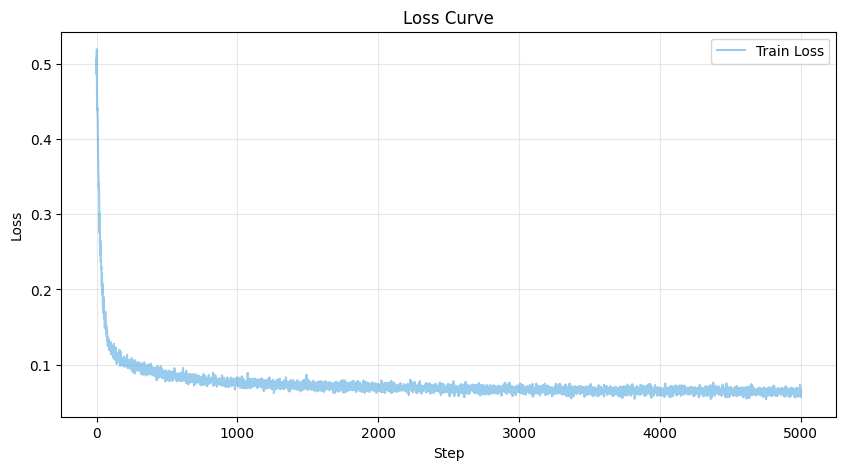

In [ ]:
if TRAIN:
    if len(losses) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(losses, label='Train Loss', color='#3498db', alpha=0.5)

        plt.title('Loss Curve')
        plt.xlabel('Step')
        plt.ylabel('Loss')
        plt.grid(True, alpha=.3)
        plt.legend()

        # saving the learning curve
        os.makedirs(args.save_folder, exist_ok=True)
        plt.savefig(f"{args.save_folder}/learning_curve.png")
        plt.show()
    else:
        print("No loss found, problems in training")

### Save model

In [ ]:
if TRAIN:
    # saving the weights
    torch.save(diffusion.state_dict(), save_path)

    print(f"Model saved")

Model saved


### Reload model

In [ ]:
if not TRAIN:
    trained_model = torch.load(save_path)

    new_state_dict = OrderedDict()
    for k, v in trained_model.items():
        new_key = k.replace('module.', '', 1)  # rimuove solo il primo 'module.'
        new_state_dict[new_key] = v

    inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
    inner_model.load_state_dict(new_state_dict)

    # Sovrascrivi func
    inner_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]

    diffusion.eval()
    print("Model loaded")

In [ ]:
if not TRAIN:
    models_to_patch = [diffusion, trainer.model, trainer.ema_model]

    for model in models_to_patch:
        m = model.module if hasattr(model, 'module') else model
        m.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
        print(f"Patched {type(m).__name__} — id: {id(m)} — func[0]: {m.func[0]}")

## Visualization

Performing the degradation and reconstruction on an image

Degradation (DCT)...
Range of Image before plotting: -1.0, 1.0
Range of Image before plotting: -1.0, 1.0
Range of Image before plotting: -1.0, 1.0
Range of Image before plotting: -1.0, 1.0


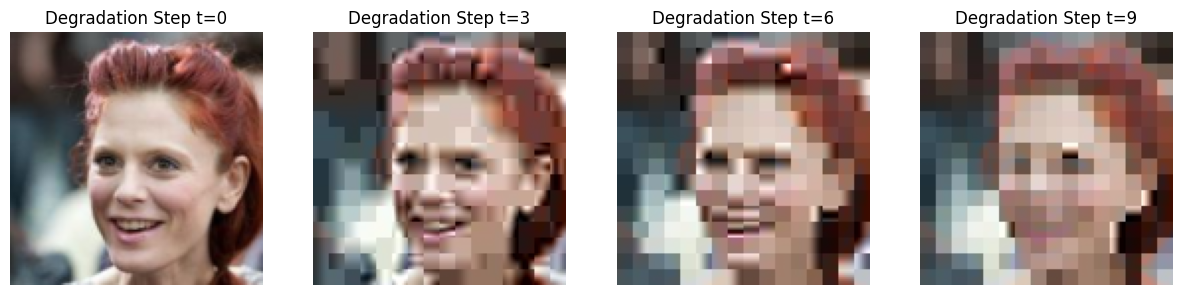

Reconstruction ...
Range of Image reconstructed before plotting: -2.2154927253723145, 2.155648708343506


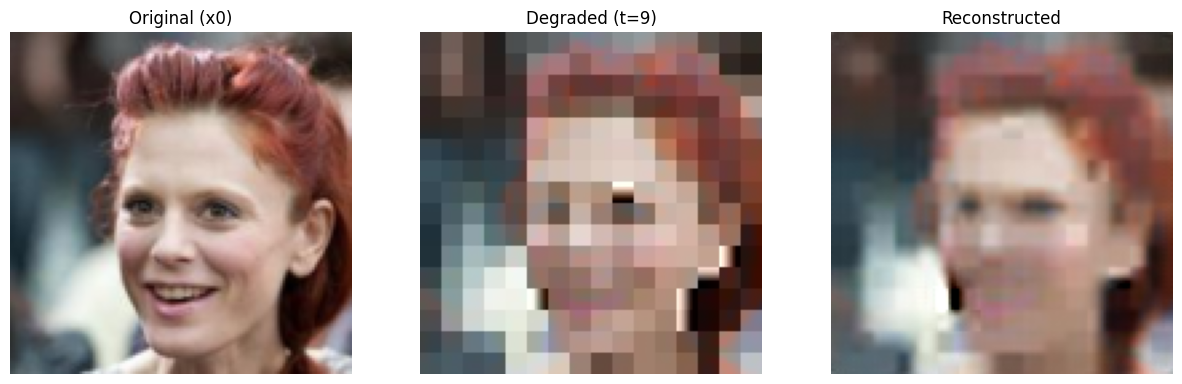

PSNR: 19.68354606628418
L1 Loss: 0.14405837655067444


In [ ]:
import torch.nn.functional as F

# preparation
# Ensure inner_model refers to the DummyWrapper instance
inner_model = diffusion

# img_path = '/content/raw_data/img_align_celeba/000001.jpg' # Using one of the generated images
x_0_pil = Image.open(img_path)     # taking first image of the batch

# Apply the same preprocessing as for training data
# Define preprocess if not already defined in the current scope
preprocess = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])
to_tensor = transforms.ToTensor()

x_0_processed = preprocess(x_0_pil)
x_0 = (to_tensor(x_0_processed) * 2) - 1 # Convert to tensor and normalize to [-1, 1]
x_0 = x_0.unsqueeze(0).to('cuda') # Add batch dimension and move to GPU

# visualization parameters
steps_to_show = [0, 3, 6, 9]
n_steps = len(steps_to_show)

# --- DEGRADATION ---
print("Degradation (DCT)...")
fig, axs = plt.subplots(1, n_steps, figsize=(15, 5))
for i, t in enumerate(steps_to_show):
    with torch.no_grad():
        x_t = inner_model.q_sample(x_0, torch.tensor([t], device='cuda'))

    # From [-1, 1] to [0, 1]
    print(f"Range of Image before plotting: {x_t.min()}, {x_t.max()}")
    img_vis = ((x_t.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
    axs[i].imshow(img_vis.clip(0, 1))
    axs[i].set_title(f"Degradation Step t={t}")
    axs[i].axis('off')
plt.show()


# --- RECONSTRUCTION ---
print("Reconstruction ...")

with torch.no_grad():    # .sample() restituisce (immagine_degradata, ricostruzione_diretta, immaginee)
    xt, direct_recons,_img = inner_model.sample(batch_size=1, img=x_t)

    print(f"Range of Image reconstructed before plotting: {_img.min()}, {_img.max()}")
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
axs[0].imshow(((x_0.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[0].set_title("Original (x0)")

# Maximum degradation
axs[1].imshow(((xt.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[1].set_title("Degraded (t=9)")

# Reconstruction
axs[2].imshow(((_img.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[2].set_title("Reconstructed")

for ax in axs: ax.axis('off')
plt.show()

psnr = calculate_psnr(x_0,_img)
print(f"PSNR: {psnr}")

l1_loss = F.l1_loss(_img, x_0).item()
print(f"L1 Loss: {l1_loss}")

# Test

In [ ]:
if TEST:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    results_psnr = []
    best_results = []
    worst_results = []

    max_test_images = 500
    processed_images = 0

    print(f"Starting testing on max {max_test_images} images...")

    diffusion.eval()

    with torch.no_grad():
        for batch in test_loader:
            if processed_images >= max_test_images:
                print("dropping last batch")
                break

            gt_tensor_norm = batch.to(device)
            curr_batch_size = min(gt_tensor_norm.shape[0], max_test_images - processed_images)
            gt_tensor_norm = gt_tensor_norm[:curr_batch_size]  # tronca l'ultimo batch se necessario

            _, _, restored_norm = diffusion.sample(batch_size=curr_batch_size, img=gt_tensor_norm)

            # Conversione in [0,1] — in-place dove possibile
            gt_01 = (gt_tensor_norm + 1).mul_(0.5)
            restored_01 = (restored_norm + 1).mul_(0.5).clamp_(0, 1)

            # Sposta su CPU una volta sola per tutto il batch
            gt_cpu = gt_01.cpu()
            restored_cpu = restored_01.cpu()

            # Libera subito la memoria GPU
            del gt_tensor_norm, restored_norm, gt_01, restored_01
            torch.cuda.empty_cache()

            for b in range(curr_batch_size):
                single_gt = gt_cpu[b:b+1]
                single_restored = restored_cpu[b:b+1]

                psnr = calculate_psnr(single_gt, single_restored)
                results_psnr.append(psnr)

                current_res = {
                    'psnr': psnr,
                    'index': processed_images,
                    'restored': single_restored,
                    'gt': single_gt
                }

                # Best 5
                if len(best_results) < 5 or psnr > best_results[-1]['psnr']:
                    best_results.append(current_res)
                    best_results.sort(key=lambda x: x['psnr'], reverse=True)
                    best_results = best_results[:5]

                # Worst 5
                if len(worst_results) < 5 or psnr < worst_results[-1]['psnr']:
                    worst_results.append(current_res)
                    worst_results.sort(key=lambda x: x['psnr'])
                    worst_results = worst_results[:5]

                processed_images += 1
                print(f"Processing {processed_images}/{max_test_images} - PSNR: {psnr:.2f} dB")

            del gt_cpu, restored_cpu
            gc.collect()

    avg_psnr = sum(results_psnr) / len(results_psnr)
    print(f"\nTest completed")
    print(f"Mean PSNR over {processed_images} images: {avg_psnr:.2f} dB")
else:
    print("Skipping testing")

Starting testing on max 500 images...
Processing 1/500 - PSNR: 27.84 dB
Processing 2/500 - PSNR: 28.58 dB
Processing 3/500 - PSNR: 27.00 dB
Processing 4/500 - PSNR: 28.32 dB
Processing 5/500 - PSNR: 29.03 dB
Processing 6/500 - PSNR: 28.63 dB
Processing 7/500 - PSNR: 26.85 dB
Processing 8/500 - PSNR: 27.02 dB
Processing 9/500 - PSNR: 25.86 dB
Processing 10/500 - PSNR: 27.13 dB
Processing 11/500 - PSNR: 29.72 dB
Processing 12/500 - PSNR: 26.64 dB
Processing 13/500 - PSNR: 30.40 dB
Processing 14/500 - PSNR: 30.44 dB
Processing 15/500 - PSNR: 29.16 dB
Processing 16/500 - PSNR: 28.26 dB
Processing 17/500 - PSNR: 30.53 dB
Processing 18/500 - PSNR: 26.38 dB
Processing 19/500 - PSNR: 25.48 dB
Processing 20/500 - PSNR: 29.05 dB
Processing 21/500 - PSNR: 29.58 dB
Processing 22/500 - PSNR: 28.72 dB
Processing 23/500 - PSNR: 27.64 dB
Processing 24/500 - PSNR: 27.30 dB
Processing 25/500 - PSNR: 29.46 dB
Processing 26/500 - PSNR: 30.22 dB
Processing 27/500 - PSNR: 29.12 dB
Processing 28/500 - PSNR: 

In [ ]:
if TEST:
  for batch in test_loader:
      gt_tensor_norm = batch.to(device)
      curr_batch_size = min(gt_tensor_norm.shape[0], max_test_images - processed_images)
      print(f"batch shape: {gt_tensor_norm.shape}")
      print(f"curr_batch_size: {curr_batch_size}")
      print(f"processed_images: {processed_images}")
      break

batch shape: torch.Size([8, 3, 128, 128])
curr_batch_size: 0
processed_images: 500


In [ ]:
if TEST:
    print(f"Media PSNR: {np.mean(results_psnr):.2f}")

    worst_5_psnr_values = [f"{item['psnr']:.2f}" for item in worst_results[:5]]
    print(f"Worst 5 PSNR: {', '.join(worst_5_psnr_values)}")

    best_5_psnr_values = [f"{item['psnr']:.2f}" for item in best_results[:5]]
    print(f"Best 5 PSNR: {', '.join(best_5_psnr_values)}")

Media PSNR: 27.87
Worst 5 PSNR: 22.98, 24.40, 24.65, 24.67, 24.82
Best 5 PSNR: 32.73, 32.53, 32.42, 31.79, 31.78


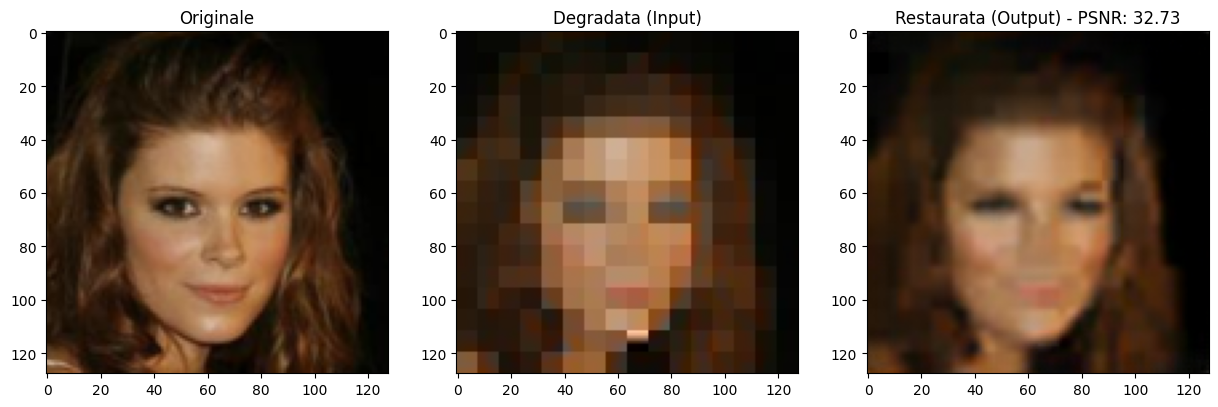

In [ ]:
if TEST:
    # Prendi il peggiore risultato salvato
    b = best_results[0]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Originale")
    plt.imshow(b['gt'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))

    # Normalize b['gt'] from [0, 1] to [-1, 1] before passing to jpeg_degradation
    normalized_gt = (b['gt'] * 2) - 1
    b['degraded'] = jpeg_degradation(normalized_gt, 9)

    plt.subplot(1, 3, 2)
    plt.title(f"Degradata (Input)")
    # Denormalize for display: from [-1, 1] back to [0, 1]
    img_display = ((b['degraded'].squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().detach().clamp(0, 1)
    plt.imshow(img_display)

    plt.subplot(1, 3, 3)
    plt.title(f"Restaurata (Output) - PSNR: {b['psnr']:.2f}")
    plt.imshow(b['restored'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))
    plt.show()

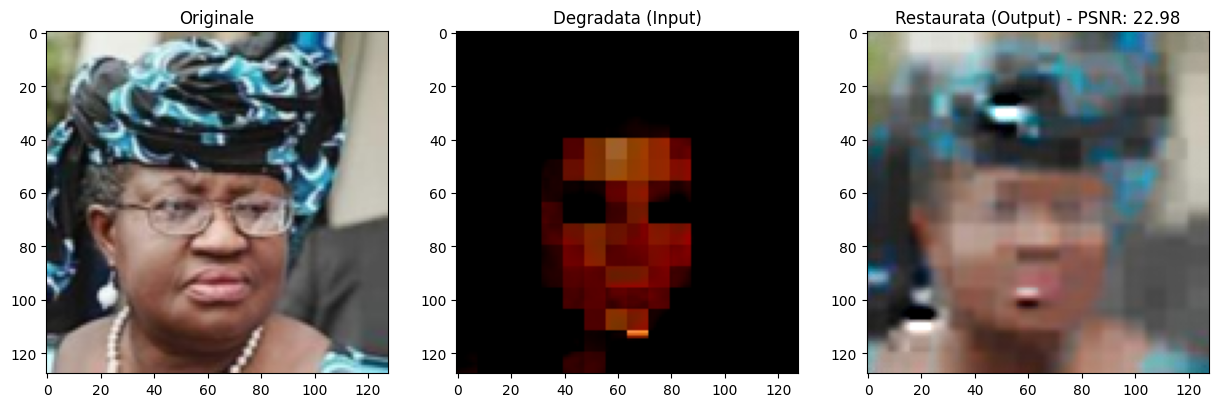

In [ ]:
if TEST:
    # Prendi il peggiore risultato salvato
    w = worst_results[0]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Originale")
    plt.imshow(w['gt'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))

    normalized_gt = (w['gt'] * 2) - 1
    w['degraded'] = jpeg_degradation(normalized_gt, 9)

    plt.subplot(1, 3, 2)
    plt.title(f"Degradata (Input)")
    plt.imshow((w['degraded'].squeeze()).permute(1, 2, 0).cpu().detach().clamp(0, 1))

    plt.subplot(1, 3, 3)
    plt.title(f"Restaurata (Output) - PSNR: {w['psnr']:.2f}")
    plt.imshow(w['restored'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))
    plt.show()